# Variables
- Distance 
- Weather
- Traffic 
- Vehicle Type 
- Preparation Time
- Courier Experice
- Delivery


# Step 2 Data Cleaning

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
print("All libraries imported successfully.")

All libraries imported successfully.


In [42]:
df = pd.read_csv('Food_Delivery_Times.csv')

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nColumn Names")
print(df.columns.tolist())

First 5 Rows
   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  

Dataset Shape
Rows: 1000, Columns: 9

Column Names
['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',

In [43]:
print("Data Types")
print(df.dtypes)

print("\nStatistical Summary")
print(df.describe())

Data Types
Order_ID                    int64
Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object

Statistical Summary
          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count  1000.000000  1000.000000           1000.000000              970.000000   
mean    500.500000    10.059970             16.982000                4.579381   
std     288.819436     5.696656              7.204553                2.914394   
min       1.000000     0.590000              5.000000                0.000000   
25%     250.750000     5.105000             11.000000                2.000000   
50%     500.500000    10.190000             17.000000                5.000000   
75%     750.250000    15.017500             23.000000                7.000000   


In [44]:
print("Missing Values per Column")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing': missing_pct})
print(missing_summary[missing_summary['Missing Count'] > 0])

print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

Missing Values per Column
                        Missing Count  Missing
Weather                            30      3.0
Traffic_Level                      30      3.0
Time_of_Day                        30      3.0
Courier_Experience_yrs             30      3.0

Total missing cells: 120


### Count Duplications

In [45]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [46]:
print("Value Range Validation")
print(f"Distance_km         : min={df['Distance_km'].min():.2f}, max={df['Distance_km'].max():.2f}")
print(f"Preparation_Time_min: min={df['Preparation_Time_min'].min()}, max={df['Preparation_Time_min'].max()}")
print(f"Courier_Experience_yrs: min={df['Courier_Experience_yrs'].min()}, max={df['Courier_Experience_yrs'].max()}")
print(f"Delivery_Time_min   : min={df['Delivery_Time_min'].min()}, max={df['Delivery_Time_min'].max()}")

print("\nUnique Categorical Values")
for col in ['Weather', 'Traffic_Level', 'Vehicle_Type', 'Time_of_Day']:
    print(f"{col}: {df[col].unique()}")

print("\nNegative or Zero Distance Records")
print(df[df['Distance_km'] <= 0].shape[0], "records")

print("Negative Delivery Time Records")
print(df[df['Delivery_Time_min'] <= 0].shape[0], "records")

Value Range Validation
Distance_km         : min=0.59, max=19.99
Preparation_Time_min: min=5, max=29
Courier_Experience_yrs: min=0.0, max=9.0
Delivery_Time_min   : min=8, max=153

Unique Categorical Values
Weather: <StringArray>
['Windy', 'Clear', 'Foggy', 'Rainy', 'Snowy', nan]
Length: 6, dtype: str
Traffic_Level: <StringArray>
['Low', 'Medium', 'High', nan]
Length: 4, dtype: str
Vehicle_Type: <StringArray>
['Scooter', 'Bike', 'Car']
Length: 3, dtype: str
Time_of_Day: <StringArray>
['Afternoon', 'Evening', 'Night', 'Morning', nan]
Length: 5, dtype: str

Negative or Zero Distance Records
0 records
Negative Delivery Time Records
0 records


In [47]:

df_clean = df.drop(columns=['Order_ID'])

traffic_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_clean['Traffic_Level_enc'] = df_clean['Traffic_Level'].map(traffic_map)

cols_needed = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs',
               'Traffic_Level_enc', 'Delivery_Time_min']
df_model = df_clean[cols_needed].dropna()

print(f"Rows before cleaning : {len(df)}")
print(f"Rows after cleaning  : {len(df_model)}")
print(f"Rows dropped         : {len(df) - len(df_model)}")
print("\nCleaned dataset preview:")
print(df_model.head())

Rows before cleaning : 1000
Rows after cleaning  : 940
Rows dropped         : 60

Cleaned dataset preview:
   Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
0         7.93                    12                     1.0   
1        16.42                    20                     2.0   
2         9.52                    28                     1.0   
3         7.44                     5                     1.0   
4        19.03                    16                     5.0   

   Traffic_Level_enc  Delivery_Time_min  
0                0.0                 43  
1                1.0                 84  
2                0.0                 59  
3                1.0                 37  
4                0.0                 68  


Findings
0 duplicates found
940+ clean records
60 Rows Dropped

## Step 3  Exploratory Data Analysis (EDA)


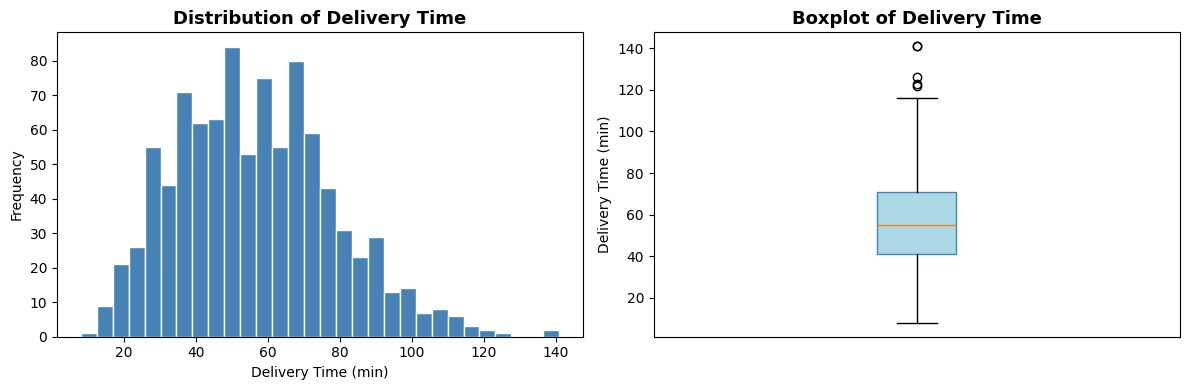


Delivery Time Statistics:
count    940.000000
mean      56.573404
std       21.941250
min        8.000000
25%       41.000000
50%       55.000000
75%       71.000000
max      141.000000
Name: Delivery_Time_min, dtype: float64


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df_model['Delivery_Time_min'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Delivery Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Delivery Time (min)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df_model['Delivery_Time_min'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'))
axes[1].set_title('Boxplot of Delivery Time', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Delivery Time (min)')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()
print("\nDelivery Time Statistics:")
print(df_model['Delivery_Time_min'].describe())

The histogram shows that delivery times are roughly bell-shaped but with a slight right skew, meaning most deliveries complete between 30–80 minutes but there is a tail of longer deliveries reaching up to ~140 minutes. The boxplot reveals several upper outliers  suggesting a small number of unusually long deliveries. The median delivery time is around 55–60 minutes. The distribution is reasonably suited for linear regression though the outliers may slightly inflate error metrics.

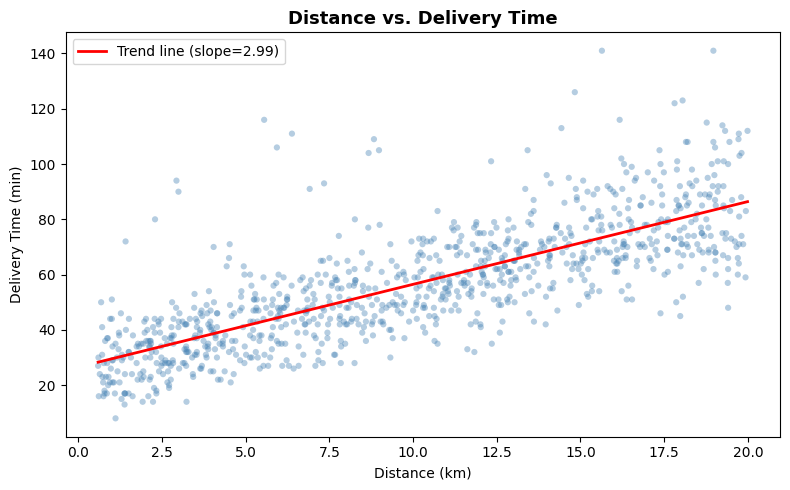

Pearson Correlation (Distance vs Delivery Time): 0.78


In [49]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_model['Distance_km'], df_model['Delivery_Time_min'],
           alpha=0.4, color='steelblue', edgecolors='none', s=20)

#trend line
z = np.polyfit(df_model['Distance_km'], df_model['Delivery_Time_min'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_model['Distance_km'].min(), df_model['Distance_km'].max(), 100)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label=f'Trend line (slope={z[0]:.2f})')

ax.set_title('Distance vs. Delivery Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Distance (km)')
ax.set_ylabel('Delivery Time (min)')
ax.legend()
plt.tight_layout()
plt.show()

corr = df_model['Distance_km'].corr(df_model['Delivery_Time_min'])
print(f"Pearson Correlation (Distance vs Delivery Time): {corr:.2f}")

There is a clear positive linear trend as distance increases, delivery time increases. The trend line has a positive slope, and the Pearson correlation is moderately strong. This makes intuitive sense a courier traveling further will naturally take longer. The scatter is relatively consistent across the range indicating homoscedasticity, which is a key assumption of linear regression. This variable is expected to be one of the strongest predictors in the model.

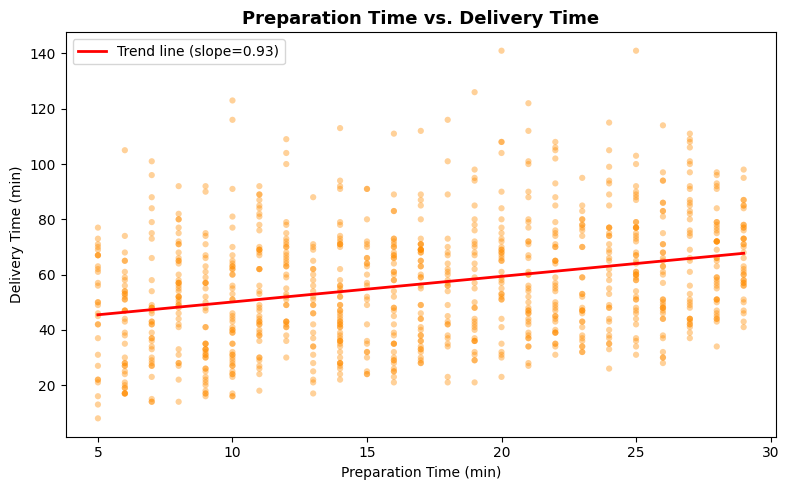

Pearson Correlation (Preparation Time vs Delivery Time): 0.3043


In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_model['Preparation_Time_min'], df_model['Delivery_Time_min'],
           alpha=0.4, color='darkorange', edgecolors='none', s=20)

z2 = np.polyfit(df_model['Preparation_Time_min'], df_model['Delivery_Time_min'], 1)
p2 = np.poly1d(z2)
x_line2 = np.linspace(df_model['Preparation_Time_min'].min(),
                      df_model['Preparation_Time_min'].max(), 100)
ax.plot(x_line2, p2(x_line2), color='red', linewidth=2, label=f'Trend line (slope={z2[0]:.2f})')

ax.set_title('Preparation Time vs. Delivery Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Preparation Time (min)')
ax.set_ylabel('Delivery Time (min)')
ax.legend()
plt.tight_layout()
plt.show()

corr2 = df_model['Preparation_Time_min'].corr(df_model['Delivery_Time_min'])
print(f"Pearson Correlation (Preparation Time vs Delivery Time): {corr2:.4f}")

A positive linear relationship is visible between preparation time and delivery time. Orders that take longer to prepare naturally result in longer overall delivery times. However, the scatter is wider compared to Distance, suggesting that preparation time alone explains less variance. The correlation value is expected to be moderate. This variable is still a meaningful predictor, as a restaurant's kitchen efficiency directly impacts customer wait time.

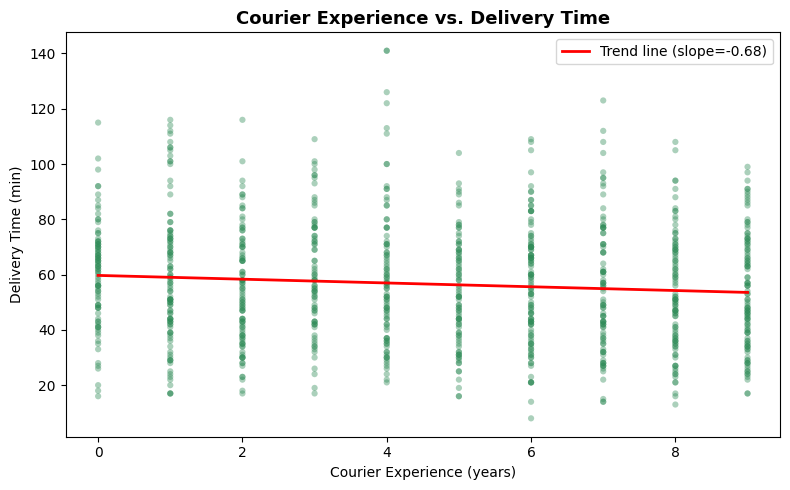

Pearson Correlation (Courier Experience vs Delivery Time): -0.0908


In [51]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(df_model['Courier_Experience_yrs'], df_model['Delivery_Time_min'],
           alpha=0.4, color='seagreen', edgecolors='none', s=20)

z3 = np.polyfit(df_model['Courier_Experience_yrs'], df_model['Delivery_Time_min'], 1)
p3 = np.poly1d(z3)
x_line3 = np.linspace(df_model['Courier_Experience_yrs'].min(),
                      df_model['Courier_Experience_yrs'].max(), 100)
ax.plot(x_line3, p3(x_line3), color='red', linewidth=2, label=f'Trend line (slope={z3[0]:.2f})')

ax.set_title('Courier Experience vs. Delivery Time', fontsize=13, fontweight='bold')
ax.set_xlabel('Courier Experience (years)')
ax.set_ylabel('Delivery Time (min)')
ax.legend()
plt.tight_layout()
plt.show()

corr3 = df_model['Courier_Experience_yrs'].corr(df_model['Delivery_Time_min'])
print(f"Pearson Correlation (Courier Experience vs Delivery Time): {corr3:.4f}")

The trend line has a negative slope, indicating that more experienced couriers deliver faster. This is logically consistent experienced couriers know optimal routes, are more efficient in navigation, and are better at handling traffic conditions. However, the correlation is expected to be weak to moderate and there is considerable scatter, meaning experience alone is not a perfect predictor. The wide spread of delivery times across all experience levels suggests that other factors play a more dominant role

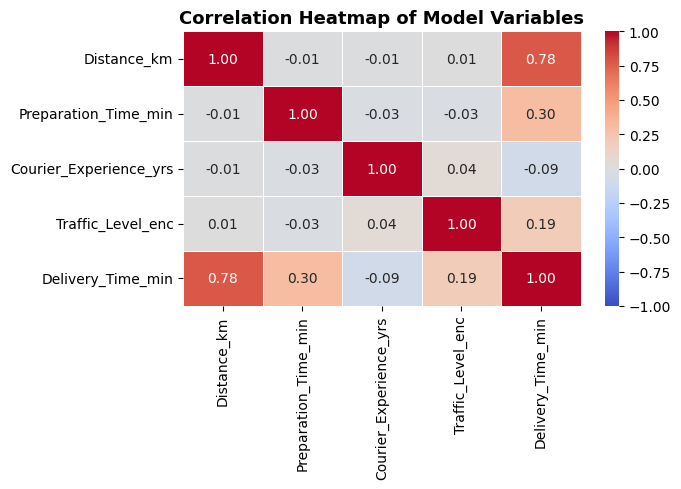

In [52]:
fig, ax = plt.subplots(figsize=(7, 5))

corr_matrix = df_model.corr()
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True  # upper triangle

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)

ax.set_title('Correlation Heatmap of Model Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The heatmap provides a comprehensive view of the linear relationships among all model variables:
- Distance_km shows the strongest positive correlation with Delivery_Time_min, confirming it as the most important predictor.
- Preparation_Time_min also has a positive correlation with the target, reinforcing its role as a meaningful predictor.
- Courier_Experience_yrs shows a negative correlation more experience leads to faster delivery.
- Traffic_Level_enc shows a modest positive correlation.
- Importantly, the predictors show low correlation with each other, suggesting minimal multicollinearity, which is a favorable condition for Multiple Linear Regression.

## STEP 4 Model Training

In [53]:
X = df_model[['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Traffic_Level_enc']]

y = df_model['Delivery_Time_min']

print("Feature Matrix X — shape:", X.shape)
print(X.head())
print("\nTarget Vector y — shape:", y.shape)
print(y.head())

Feature Matrix X — shape: (940, 4)
   Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
0         7.93                    12                     1.0   
1        16.42                    20                     2.0   
2         9.52                    28                     1.0   
3         7.44                     5                     1.0   
4        19.03                    16                     5.0   

   Traffic_Level_enc  
0                0.0  
1                1.0  
2                0.0  
3                1.0  
4                0.0  

Target Vector y — shape: (940,)
0    43
1    84
2    59
3    37
4    68
Name: Delivery_Time_min, dtype: int64


In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size  : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set size : 752 rows (80.0%)
Testing set size  : 188 rows (20.0%)


In [55]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
print(f"Intercept: {model.intercept_:.4f}")
print("\nCoefficients:")
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coeff_df.to_string(index=False))

print("\nModel Equation:")
equation = f"Delivery_Time = {model.intercept_:.2f}"
for feat, coef in zip(X.columns, model.coef_):
    sign = '+' if coef >= 0 else '-'
    equation += f" {sign} {abs(coef):.4f}×{feat}"
print(equation)

Intercept: 8.3619

Coefficients:
               Feature  Coefficient
           Distance_km     2.978243
  Preparation_Time_min     0.969553
Courier_Experience_yrs    -0.625728
     Traffic_Level_enc     5.558024

Model Equation:
Delivery_Time = 8.36 + 2.9782×Distance_km + 0.9696×Preparation_Time_min - 0.6257×Courier_Experience_yrs + 5.5580×Traffic_Level_enc


## Step 6 Performance Evaluation

In [57]:
y_pred = model.predict(X_test)

results_df = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred.round(2)})
print("Sample of Actual vs. Predicted Values:")
print(results_df.head(10).to_string(index=False))

Sample of Actual vs. Predicted Values:
 Actual  Predicted
     42      38.56
     68      70.64
     28      39.65
     34      40.15
     91      50.11
     57      72.29
     46      43.55
     65      62.59
     34      32.08
     72      66.34


In [58]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)


print("      MODEL PERFORMANCE METRICS")
print("\n")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Sq. Error: {rmse:.2f}")
print(f"Coefficient of Det: {r2:.2f}")

      MODEL PERFORMANCE METRICS


Mean Absolute Error: 7.94
Mean Squared Error: 175.57
Root Mean Sq. Error: 13.25
Coefficient of Det: 0.69


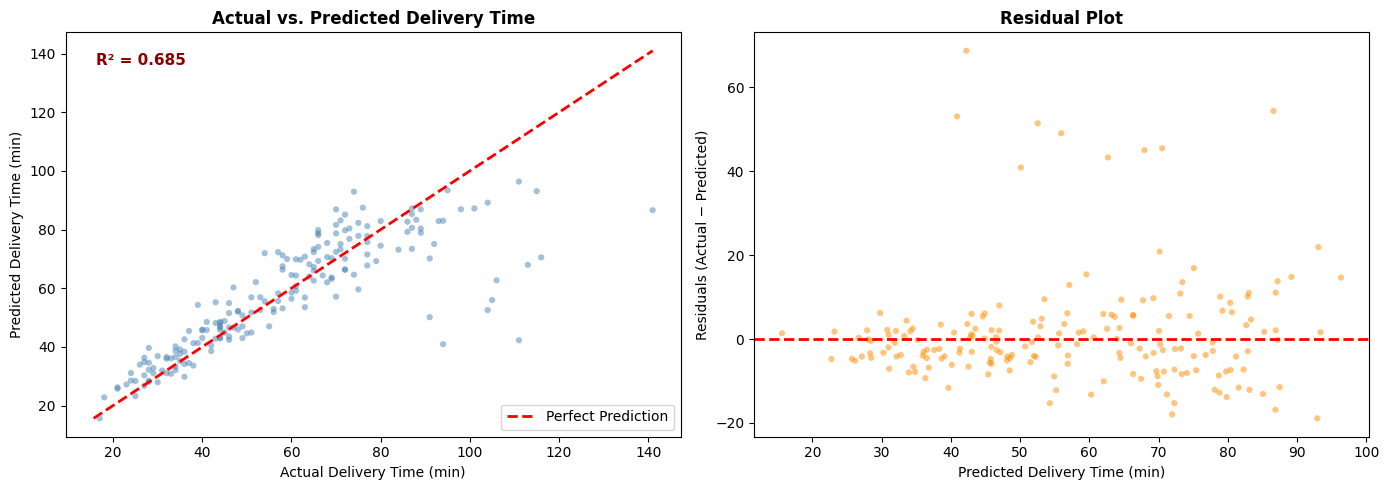

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#plot 1 Scatter of Actual vs Predicted 
axes[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='none', s=20)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Actual vs. Predicted Delivery Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Delivery Time (min)')
axes[0].set_ylabel('Predicted Delivery Time (min)')
axes[0].legend()
axes[0].text(0.05, 0.92, f'R² = {r2:.3f}', transform=axes[0].transAxes,
             fontsize=11, color='darkred', fontweight='bold')

#plot2
residuals = y_test.values - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.5, color='darkorange', edgecolors='none', s=20)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Delivery Time (min)')
axes[1].set_ylabel('Residuals (Actual − Predicted)')

plt.tight_layout()
plt.show()


## Reflection and Analysis

#### Q1. Do the selected variables significantly affect delivery time?

Yes, the selected variables collectively and individually show meaningful relationships with delivery time, as confirmed by both EDA and the regression coefficients:
- Distance has the strongest positive correlation  longer trips directly mean more time.
- Preparation Time positively contributes since the courier must wait for the order to be ready.
- Courier Experience negatively affects delivery time  experienced couriers are more efficient.
- Traffic Level positively affects delivery time  congestion slows delivery.
#### Q2. What are the limitations of the model and dataset?

Limitation  Description 
 Linearity assumption  MLR assumes a linear relationship, which may not fully capture complex interactions 
 Missing variables Factors like road type, exact weather severity, restaurant location density, and order size are absent 
 Categorical encoding  Traffic_Level was encoded ordinally , which assumes equal spacing between categories 
 Outliers  A few extreme delivery times (>120 min) may disproportionately influence the model 
 Missing data handling Rows with missing values were dropped, potentially introducing selection bias 
 Synthetic dataset  The dataset is from Kaggle and likely generated/simulated, so real-world noise may not be fully represented 

#### Q3. Which variable contributes the most to delivery time? Justify using EDA and coefficients.

Distance_km is the strongest predictor, supported by:
1. EDA: It has the highest Pearson correlation with Delivery_Time_min among all predictors.
2. Scatter plot: The Distance vs. Delivery Time plot shows the clearest linear trend.
3. Coefficient: Distance_km has the largest coefficient in the regression model, meaning each additional kilometer adds the most minutes to estimated delivery time compared to other variables.


#### Q4. If the strongest predictor is removed, what will happen to model performance?

Removing Distance_km would significantly degrade model performance:
- R² would decrease substantially, as the model loses its most explanatory variable.
- MAE and RMSE would increase, meaning predictions would be less accurate on average.
- The model would rely more heavily on Preparation_Time_min and Traffic_Level_enc, which have weaker individual correlations.
- Logically, without knowing *how far* the courier must travel, the model cannot accurately predict arrival time, regardless of how efficient the courier is or how well-prepared the restaurant is.

#### Q5. Does correlation imply causation in this dataset? Explain using an example.

No correlation does not imply causation, even when strong statistical relationships are observed.

There is a positive correlation between Preparation_Time_min and Delivery_Time_min. However, this does not mean preparation time causes longer deliveries in isolation. A confounding factor like restaurant complexity or order size could simultaneously cause longer prep times and longer deliveries. A large, multi-item order takes longer to prepare AND is often for a table further away. The correlation between prep time and delivery time may therefore reflect this underlying confounder rather than a direct causal link.
